In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('football.csv')

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8925 entries, 0 to 8924
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   matchId                8925 non-null   object 
 1   playerId               8925 non-null   object 
 2   playType               8925 non-null   object 
 3   bodyPart               8925 non-null   object 
 4   x                      8925 non-null   float64
 5   y                      8925 non-null   float64
 6   interveningOpponents   8925 non-null   int64  
 7   interveningTeammates   8925 non-null   int64  
 8   interferenceOnShooter  8891 non-null   object 
 9   minute                 8925 non-null   int64  
 10  second                 8925 non-null   int64  
 11  outcome                8891 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 836.8+ KB
None
                 x            y  interveningOpponents  interveningTeammates  \
count  8925.00000

c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


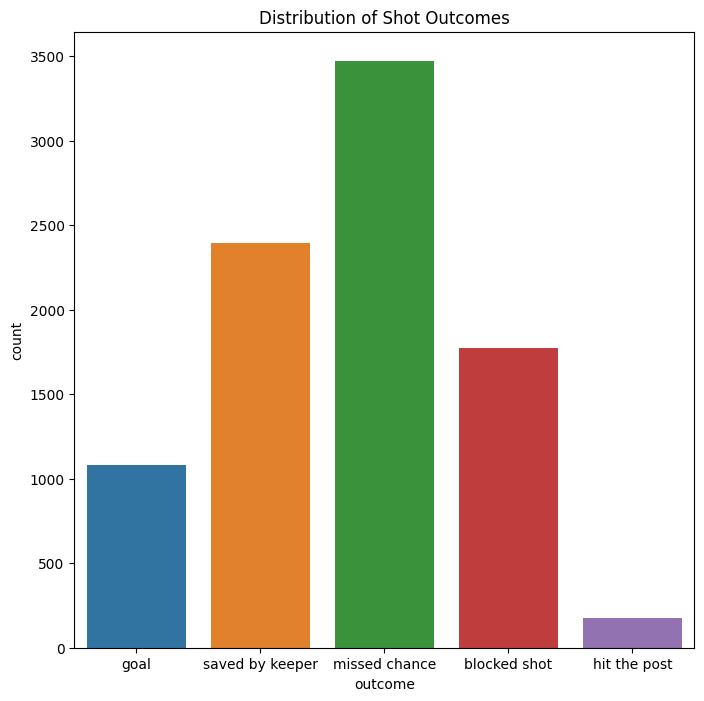

c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\Hasti\anaconda3\envs\quera\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


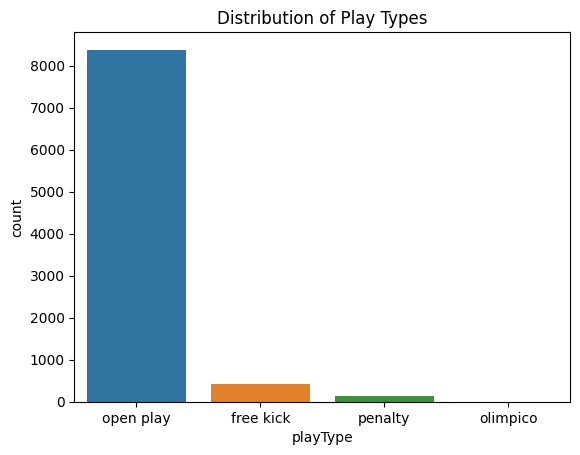

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the distribution of shot outcomes
plt.figure(figsize=(8, 8))
sns.countplot(x='outcome', data=df)
plt.title('Distribution of Shot Outcomes')
plt.show()

# Visualize the distribution of play types
sns.countplot(x='playType', data=df)
plt.title('Distribution of Play Types')
plt.show()

In [3]:
df['outcome'] = df['outcome'].replace({'own goal': 'goal'})
df['outcome'] = (df['outcome'] == 'goal')

In [4]:
df['matchId'] = df['matchId'].str.extract('(\d+)').astype(int)
df['playerId'] = df['playerId'].str.extract('(\d+)').astype(int)

In [5]:
#from sklearn.preprocessing import LabelEncoder

#label_encoder = LabelEncoder()
#categorical_columns = ['playType', 'bodyPart', 'interferenceOnShooter']
#df_numeric = df.copy()
#for col in categorical_columns:
 #   df_numeric[col] = label_encoder.fit_transform(df_numeric[col])
  #  print("Classes:", label_encoder.classes_)

In [6]:
df

,matchId,playerId,playType,bodyPart,x,y,interveningOpponents,interveningTeammates,interferenceOnShooter,minute,second,outcome
0,91,103,open play,right foot,13.47,-11.22,1,0,medium,70,9,True
1,17,16,open play,left foot,9.48,14.22,3,0,medium,55,4,False
2,111,88,free kick,left foot,29.43,-1.25,6,2,low,86,31,False
3,142,87,open play,right foot,26.93,1.00,4,1,medium,77,2,False
4,117,9,open play,right foot,10.72,5.24,2,0,medium,76,46,True
...,...,...,...,...,...,...,...,...,...,...,...,...
8920,57,115,open play,head,6.48,3.99,3,0,high,69,50,False
8921,59,76,open play,right foot,21.45,-8.73,4,1,medium,15,53,False
8922,55,150,open play,left foot,11.97,3.24,3,0,medium,84,34,False
8923,33,130,open play,right foot,6.48,-6.98,1,0,high,4,39,False


In [7]:
categorical_columns = ['playType', 'bodyPart', 'interferenceOnShooter']

# Use pd.get_dummies for one-hot encoding
df_cp = pd.get_dummies(df, columns=categorical_columns)

In [8]:
df_cp

,matchId,playerId,x,y,interveningOpponents,interveningTeammates,minute,second,outcome,playType_free kick,playType_olimpico,playType_open play,playType_penalty,bodyPart_head,bodyPart_left foot,bodyPart_other,bodyPart_right foot,interferenceOnShooter_high,interferenceOnShooter_low,interferenceOnShooter_medium
0,91,103,13.47,-11.22,1,0,70,9,True,False,False,True,False,False,False,False,True,False,False,True
1,17,16,9.48,14.22,3,0,55,4,False,False,False,True,False,False,True,False,False,False,False,True
2,111,88,29.43,-1.25,6,2,86,31,False,True,False,False,False,False,True,False,False,False,True,False
3,142,87,26.93,1.00,4,1,77,2,False,False,False,True,False,False,False,False,True,False,False,True
4,117,9,10.72,5.24,2,0,76,46,True,False,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8920,57,115,6.48,3.99,3,0,69,50,False,False,False,True,False,True,False,False,False,True,False,False
8921,59,76,21.45,-8.73,4,1,15,53,False,False,False,True,False,False,False,False,True,False,False,True
8922,55,150,11.97,3.24,3,0,84,34,False,False,False,True,False,False,True,False,False,False,False,True
8923,33,130,6.48,-6.98,1,0,4,39,False,False,False,True,False,False,False,False,True,True,False,False


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

X = df_cp.drop(columns=['outcome'])
y = df_cp['outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate the model
print(f'Accuracy before feature engineering: {accuracy_score(y_test, y_pred)}')

Accuracy before feature engineering: 0.8879761015683346


In [10]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information
mutual_info = mutual_info_classif(X_train, y_train)

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': mutual_info})

# Sort the DataFrame by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display the results
print(feature_importance)

                         Feature  Importance
4           interveningOpponents    0.035399
2                              x    0.033966
3                              y    0.033769
11              playType_penalty    0.009840
1                       playerId    0.008283
9              playType_olimpico    0.006305
0                        matchId    0.005681
5           interveningTeammates    0.004144
8             playType_free kick    0.003623
17     interferenceOnShooter_low    0.002780
6                         minute    0.002240
7                         second    0.001570
13            bodyPart_left foot    0.001248
10            playType_open play    0.000000
12                 bodyPart_head    0.000000
14                bodyPart_other    0.000000
15           bodyPart_right foot    0.000000
16    interferenceOnShooter_high    0.000000
18  interferenceOnShooter_medium    0.000000


After

In [11]:
# Fill nulls with 'low' where interveningOpponents is 0
df.loc[(df['interferenceOnShooter'].isnull()) & (df['interveningOpponents'] == 0), 'interferenceOnShooter'] =  'low'

# Fill nulls with 'medium' where interveningOpponents is 1
df.loc[(df['interferenceOnShooter'].isnull()) & (df['interveningOpponents'] == 1), 'interferenceOnShooter'] = 'medium'

# Fill nulls with 'high' where interveningOpponents is 2 or more
df.loc[(df['interferenceOnShooter'].isnull()) & (df['interveningOpponents'] > 1), 'interferenceOnShooter'] = 'high'


In [12]:
most_frequent_value = df['outcome'].mode()[0]
df['outcome'].fillna(most_frequent_value, inplace=True)

In [13]:
df['bodyPart'].replace({'right foot': 'foot', 'left foot': 'foot'}, inplace=True)

In [14]:
df

,matchId,playerId,playType,bodyPart,x,y,interveningOpponents,interveningTeammates,interferenceOnShooter,minute,second,outcome
0,91,103,open play,foot,13.47,-11.22,1,0,medium,70,9,True
1,17,16,open play,foot,9.48,14.22,3,0,medium,55,4,False
2,111,88,free kick,foot,29.43,-1.25,6,2,low,86,31,False
3,142,87,open play,foot,26.93,1.00,4,1,medium,77,2,False
4,117,9,open play,foot,10.72,5.24,2,0,medium,76,46,True
...,...,...,...,...,...,...,...,...,...,...,...,...
8920,57,115,open play,head,6.48,3.99,3,0,high,69,50,False
8921,59,76,open play,foot,21.45,-8.73,4,1,medium,15,53,False
8922,55,150,open play,foot,11.97,3.24,3,0,medium,84,34,False
8923,33,130,open play,foot,6.48,-6.98,1,0,high,4,39,False


In [15]:
df.drop(columns=['matchId', 'playerId'], inplace=True)

In [16]:
df['distance'] = np.sqrt(df['x']**2 + df['y']**2)

In [17]:
# Enhance Distance Calculation
df['angle'] = np.arctan2(df['y'], df['x'])  # Calculate angle

In [18]:
categorical_columns = ['playType', 'bodyPart', 'interferenceOnShooter']

# Use pd.get_dummies for one-hot encoding
df_numeric = pd.get_dummies(df, columns=categorical_columns)

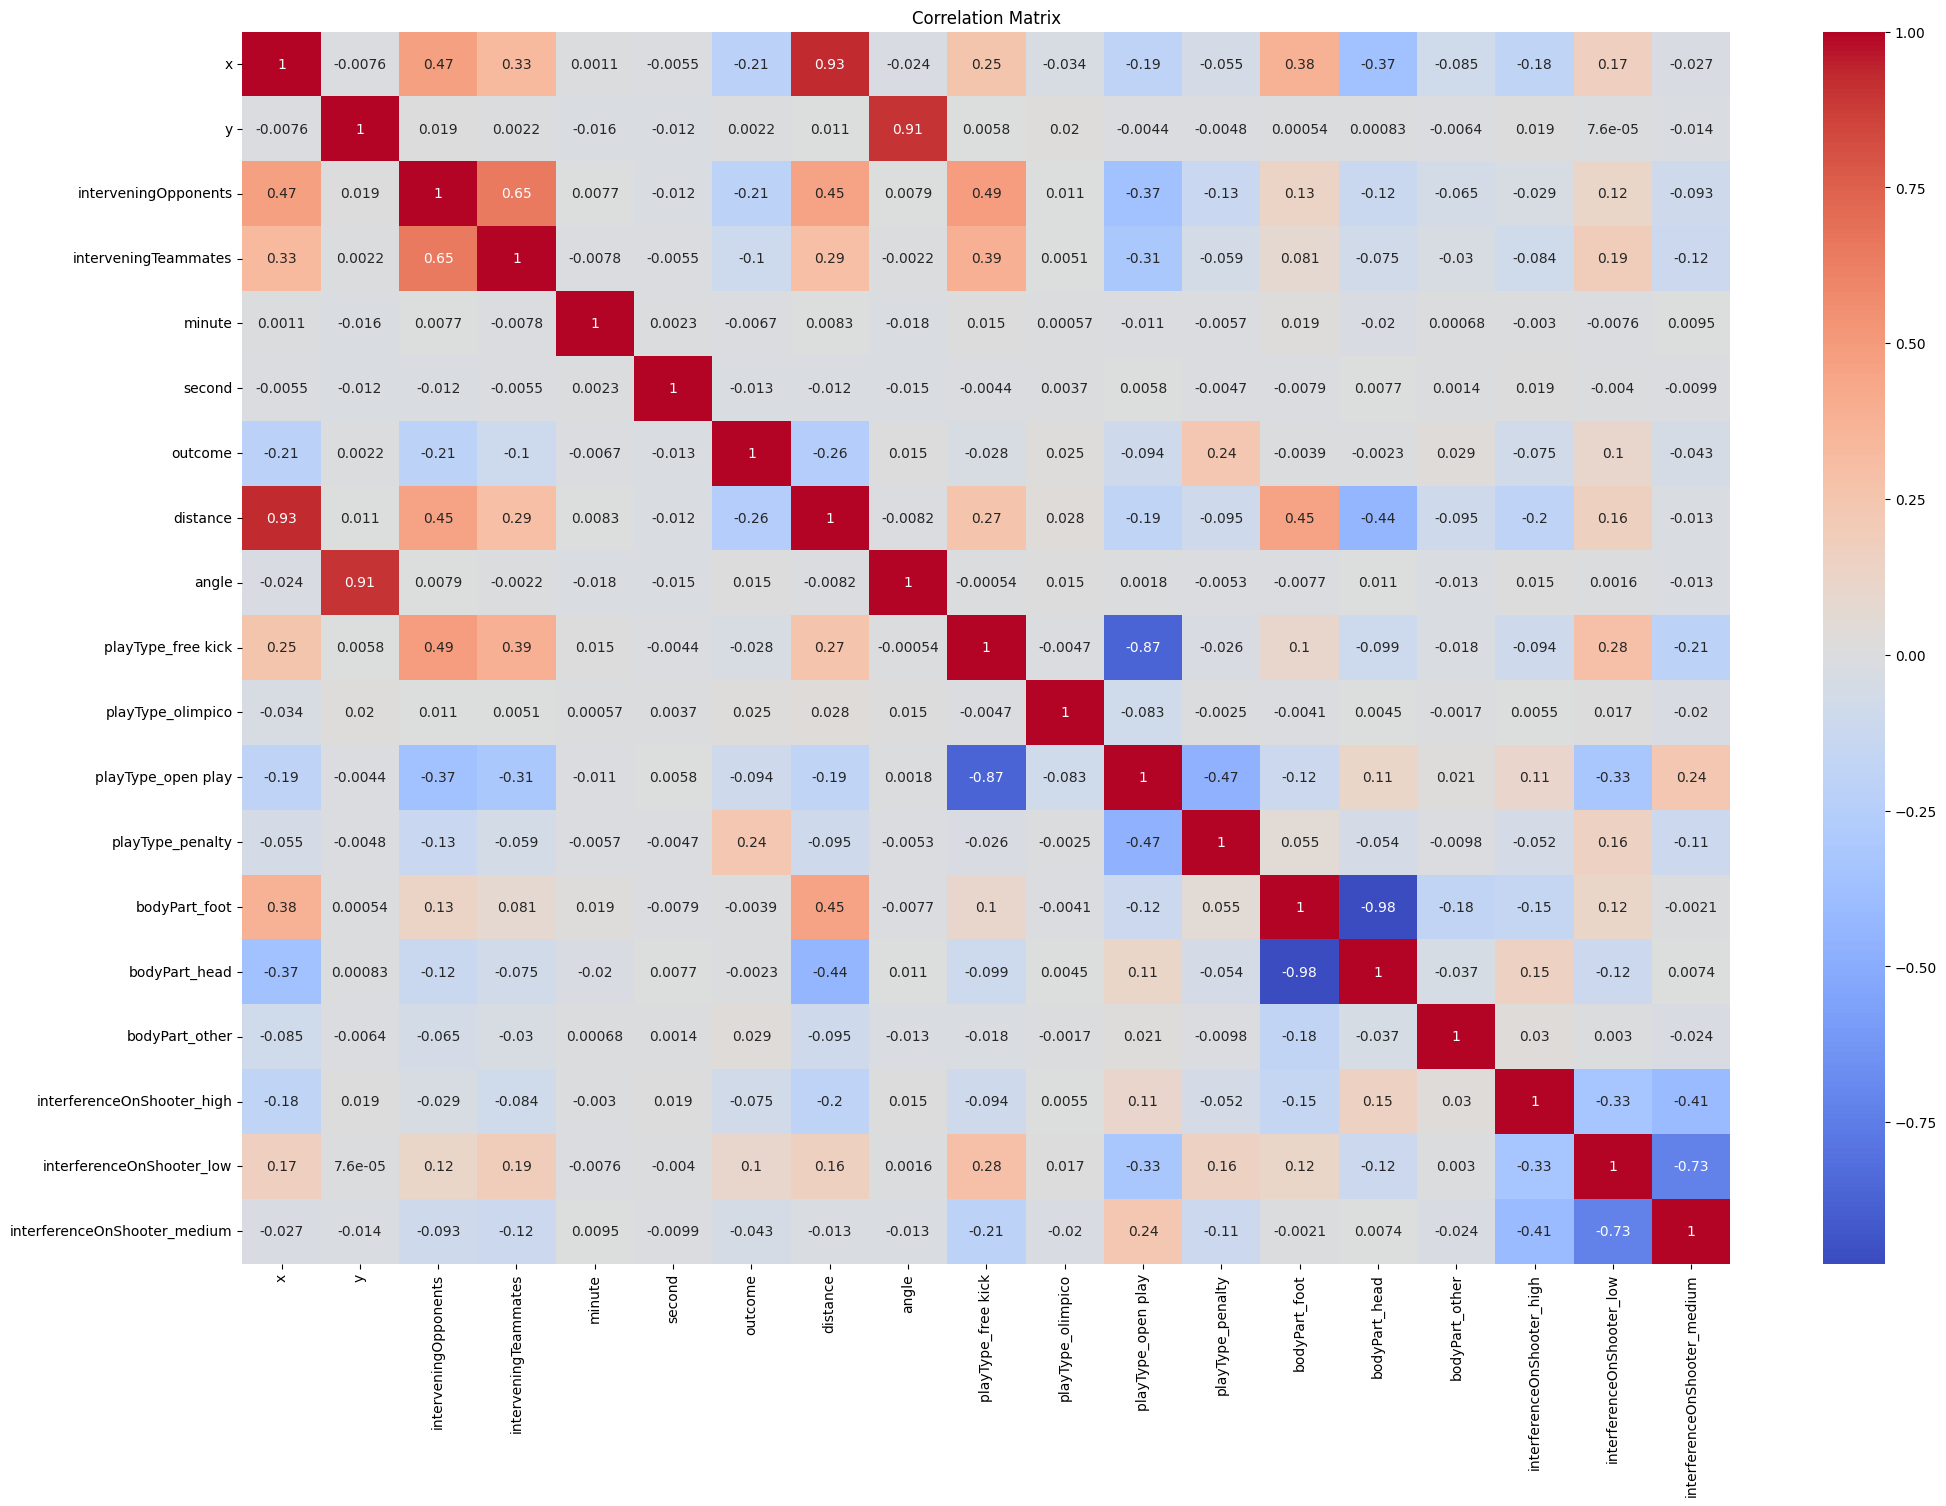

In [19]:
# Check correlations between numeric features
plt.figure(figsize=(24, 16)) 
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [20]:
low_importance_features = feature_importance[feature_importance['Importance'] < 0.005]['Feature']
for column in df.columns:
    for unimportant_feature in low_importance_features:
        if unimportant_feature.startswith(column):
            df.drop(columns=[column], inplace=True)
            break

In [21]:
df

,x,y,interveningOpponents,outcome,distance,angle
0,13.47,-11.22,1,True,17.530810,-0.694519
1,9.48,14.22,3,False,17.090313,0.982794
2,29.43,-1.25,6,False,29.456534,-0.042448
3,26.93,1.00,4,False,26.948560,0.037116
4,10.72,5.24,2,True,11.932141,0.454652
...,...,...,...,...,...,...
8920,6.48,3.99,3,False,7.609895,0.551913
8921,21.45,-8.73,4,False,23.158484,-0.386520
8922,11.97,3.24,3,False,12.400746,0.264342
8923,6.48,-6.98,1,False,9.524222,-0.822528


In [22]:


# Combine Opponents and Teammates
#df['intervening_players'] = df['interveningOpponents'] + df['interveningTeammates']

# Select Top Features for Modeling
#top_features = ['distance', 'interveningOpponents', 'x', 'y', 'angle']
#X = df_numeric[top_features]
y = df_numeric['outcome']

# Train a model using the selected features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

In [23]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information
mutual_info = mutual_info_classif(X_train, y_train)

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': mutual_info})

# Sort the DataFrame by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Display the results
print(feature_importance)

                         Feature  Importance
2                              x    0.039669
3                              y    0.036287
4           interveningOpponents    0.035886
11              playType_penalty    0.017612
17     interferenceOnShooter_low    0.012915
5           interveningTeammates    0.011492
16    interferenceOnShooter_high    0.008437
18  interferenceOnShooter_medium    0.005878
9              playType_olimpico    0.005777
0                        matchId    0.004772
13            bodyPart_left foot    0.004187
10            playType_open play    0.003697
12                 bodyPart_head    0.002359
7                         second    0.002332
14                bodyPart_other    0.001630
1                       playerId    0.000000
8             playType_free kick    0.000000
15           bodyPart_right foot    0.000000
6                         minute    0.000000


In [24]:
print(df_numeric)

          x      y  interveningOpponents  interveningTeammates  minute  \
0     13.47 -11.22                     1                     0      70   
1      9.48  14.22                     3                     0      55   
2     29.43  -1.25                     6                     2      86   
3     26.93   1.00                     4                     1      77   
4     10.72   5.24                     2                     0      76   
...     ...    ...                   ...                   ...     ...   
8920   6.48   3.99                     3                     0      69   
8921  21.45  -8.73                     4                     1      15   
8922  11.97   3.24                     3                     0      84   
8923   6.48  -6.98                     1                     0       4   
8924   8.23  26.43                     2                     0      72   

      second  outcome   distance     angle  playType_free kick  \
0          9     True  17.530810 -0.694519   

In [25]:
y_pred = clf.predict(X_test)

# Evaluate the model
print(f'Accuracy after feature engineering: {accuracy_score(y_test, y_pred)}')

Accuracy after feature engineering: 0.884593837535014
